In [1]:
import pandas as pd

In [8]:
df = pd.read_csv("../X_train.csv", sep=';')

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier # Ou Regressor selon ta cible

# 1. Chargement des données
X = pd.read_csv('../X_train.csv', sep=';')
y = pd.read_csv('../y_train.csv', sep=';')

X.head()


,id,album,artist,artists,aspect_ratio,channel,description,video_duration,format,release_year,track,uploader,filepath,download_timing,uploader_short,vid,uid
0,7602656035161050390,NaN,Urhov Bogdan,['Urhov Bogdan'],0.56,Davos Klosters,you dream you 🥹 #davosklosters #skiing #mounta...,13,1080x1920,2026,оригинальный звук,davosklosters,downloads/USER_davosklosters/VIDEO_76026560351...,2026-02-12 09:29:25,davos,VIDEO_7602656035161050390,USER_davosklosters
1,7590718903144287510,NaN,LykTraffx,['LykTraffx'],0.56,Davos Klosters,already missing this again 🥹 #spenglercup #dav...,12,1080x1920,2026,оригинальный звук,davosklosters,downloads/USER_davosklosters/VIDEO_75907189031...,2026-02-12 09:29:25,davos,VIDEO_7590718903144287510,USER_davosklosters
2,7571821778746592534,NaN,ALTÉGO,['ALTÉGO'],0.56,Davos Klosters,how??!!!🥹🥹 #davosklosters #skiing #ski #season...,13,1080x1920,2025,THE FATE OF OPHELIA X MIDNIGHT CITY,davosklosters,downloads/USER_davosklosters/VIDEO_75718217787...,2026-02-12 09:29:25,davos,VIDEO_7571821778746592534,USER_davosklosters
3,7569927329154190614,NaN,Raye,['Raye'],0.56,Davos Klosters,We're back on snow!🥹🎿 #davosklosters #seasonop...,7,1080x1920,2025,original sound,davosklosters,downloads/USER_davosklosters/VIDEO_75699273291...,2026-02-12 09:29:25,davos,VIDEO_7569927329154190614,USER_davosklosters
4,7566270741134462230,NaN,músicas e traduções,['músicas e traduções'],0.56,Davos Klosters,"Somebody send help, pls. 🥶 #davos #firstsnow #...",8,1080x1920,2025,som original,davosklosters,downloads/USER_davosklosters/VIDEO_75662707411...,2026-02-12 09:29:25,davos,VIDEO_7566270741134462230,USER_davosklosters


In [22]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1348 entries, 0 to 1347
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1348 non-null   int64  
 1   album            375 non-null    object 
 2   artist           1317 non-null   object 
 3   artists          1317 non-null   object 
 4   aspect_ratio     1348 non-null   float64
 5   channel          1348 non-null   object 
 6   description      1343 non-null   object 
 7   video_duration   1348 non-null   int64  
 8   format           1348 non-null   object 
 9   release_year     1348 non-null   int64  
 10  track            1322 non-null   object 
 11  uploader         1348 non-null   object 
 12  filepath         1348 non-null   object 
 13  download_timing  1348 non-null   object 
 14  uploader_short   1348 non-null   object 
 15  vid              1348 non-null   object 
 16  uid              1348 non-null   object 
dtypes: float64(1),

In [23]:
print("Colonnes de y :", y.columns.tolist())
print("\nPremières lignes :")
print(y.head())

Colonnes de y : ['ID', 'popularity']

Premières lignes :
                    ID  popularity
0  7602656035161050390    8.603777
1  7590718903144287510    8.537734
2  7571821778746592534   11.208495
3  7569927329154190614   11.982352
4  7566270741134462230    8.678487


In [24]:
# On cible la colonne 'popularity'
stats_pop = y['popularity'].describe()
print("\nStatistiques de la popularité :")
print(stats_pop)


Statistiques de la popularité :
count    1348.000000
mean        7.804249
std         1.686488
min         3.487629
25%         6.724373
50%         7.497118
75%         8.772238
max        14.407981
Name: popularity, dtype: float64


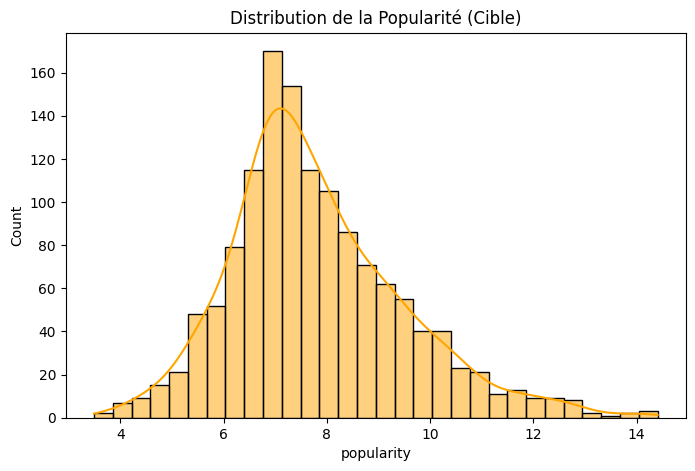

In [25]:
plt.figure(figsize=(8, 5))
sns.histplot(y['popularity'], kde=True, color='orange')
plt.title("Distribution de la Popularité (Cible)")
plt.show()